In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder

xgb_model = joblib.load(r"C:\Research\EndpointXAI\models\xgboost.pkl")
label_encoder = joblib.load(r"C:\Research\EndpointXAI\models\label_encoder.pkl")

X_train = pd.read_csv(r"C:\Research\EndpointXAI\data\X_train.csv")
X_test = pd.read_csv(r"C:\Research\EndpointXAI\data\X_test.csv")
y_test = pd.read_csv(r"C:\Research\EndpointXAI\data\y_test.csv").squeeze()

# Encode string columns (pandas 3 uses str dtype instead of object)
string_cols = X_train.select_dtypes(include=["object", "str"]).columns.tolist()
if string_cols:
    oe = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
    X_train[string_cols] = oe.fit_transform(X_train[string_cols])
    X_test[string_cols] = oe.transform(X_test[string_cols])
    print(f"Encoded columns: {string_cols}")

print(f"Loaded model and data ✅")
print(f"Test data shape: {X_test.shape}")
print(f"Classes: {list(label_encoder.classes_)}")


Encoded columns: ['Channel', 'SourceName', 'SourceModuleName', 'Severity', 'AccountName', 'AccountType']
Loaded model and data ✅
Test data shape: (9125, 10)
Classes: ['defense_evasion', 'lateral_movement', 'persistence']


In [2]:
import shap

# Create the SHAP explainer (this learns the model's logic)
print("Building SHAP explainer... ⏳")
explainer = shap.TreeExplainer(xgb_model)
print("Explainer ready ✅")

Building SHAP explainer... ⏳
Explainer ready ✅


In [3]:
# Sample 1000 events for explanation (full set is slow)
sample_size = 1000
X_sample = X_test.sample(n=sample_size, random_state=42)

print(f"Calculating SHAP values for {sample_size} events... ⏳")
print("(this might take 30-60 seconds)")

shap_values = explainer.shap_values(X_sample)

# Newer SHAP returns 3D array (samples, features, classes).
# Normalise to a list of 2D arrays, one per class.
import numpy as np
if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    shap_values = [shap_values[:, :, i] for i in range(shap_values.shape[2])]

print(f"\nSHAP values calculated ✅")
print(f"Classes: {len(shap_values)}, Shape per class: {shap_values[0].shape}")


Calculating SHAP values for 1000 events... ⏳
(this might take 30-60 seconds)

SHAP values calculated ✅
Classes: 3, Shape per class: (1000, 10)


Global Feature Importance (top features that drive ALL predictions)


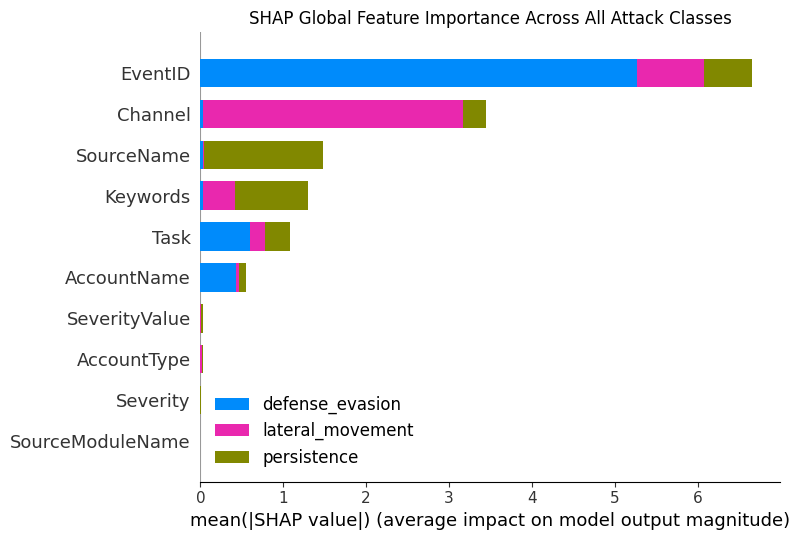

In [4]:
import os
os.makedirs(r"C:\Research\EndpointXAI\xai", exist_ok=True)

print("Global Feature Importance (top features that drive ALL predictions)")

shap.summary_plot(
    shap_values,
    X_sample,
    class_names=label_encoder.classes_,
    plot_type="bar",
    show=False
)
plt.title("SHAP Global Feature Importance Across All Attack Classes")
plt.tight_layout()
plt.savefig(r"C:\Research\EndpointXAI\xai\shap_global_importance.png", dpi=150, bbox_inches="tight")
plt.show()


Top features for: defense_evasion


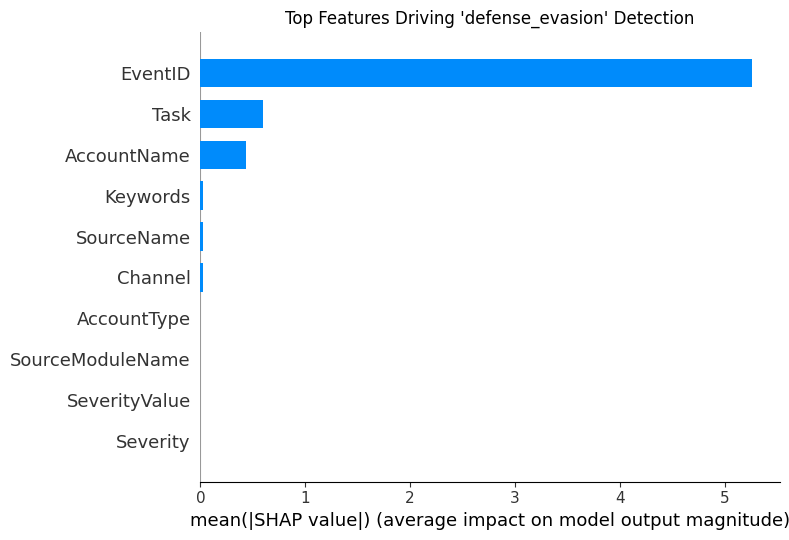

Top features for: lateral_movement


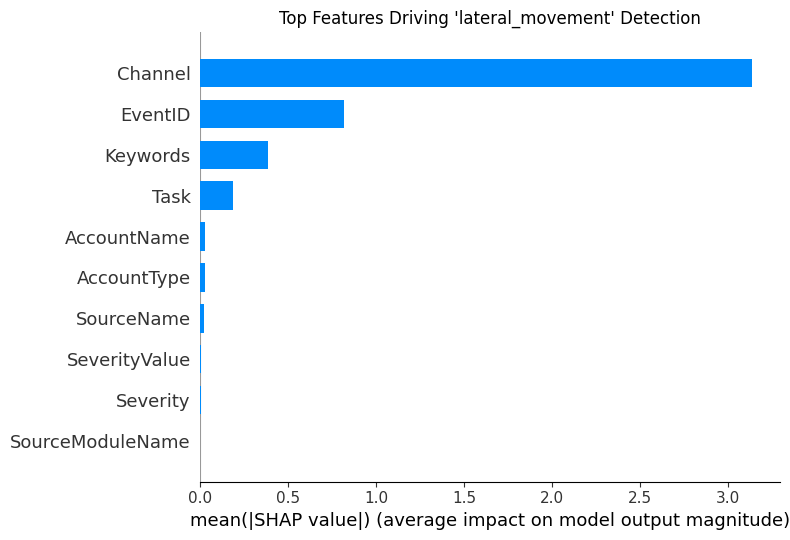

Top features for: persistence


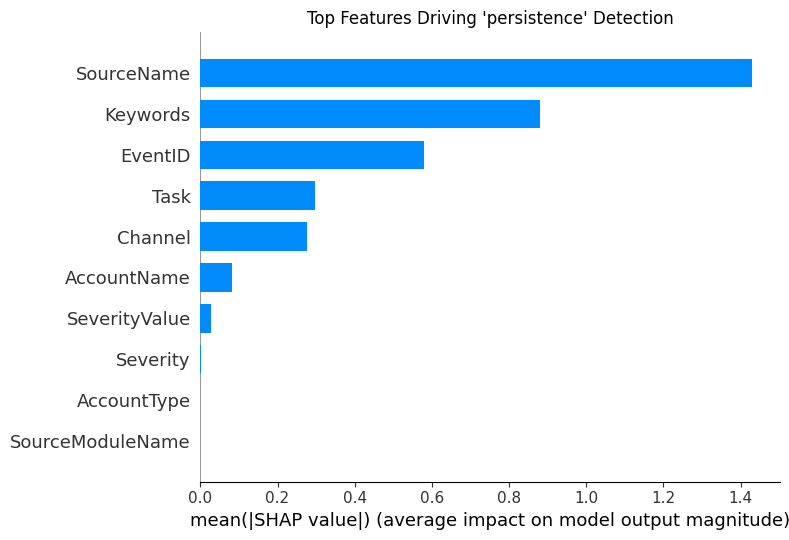

In [5]:
# Generate one summary plot per attack class
for i, class_name in enumerate(label_encoder.classes_):
    print(f"Top features for: {class_name}")

    plt.figure()
    shap.summary_plot(
        shap_values[i],
        X_sample,
        show=False,
        plot_type="bar"
    )
    plt.title(f"Top Features Driving '{class_name}' Detection")
    plt.tight_layout()
    plt.savefig(rf"C:\Research\EndpointXAI\xai\shap_{class_name}.png", dpi=150, bbox_inches="tight")
    plt.show()


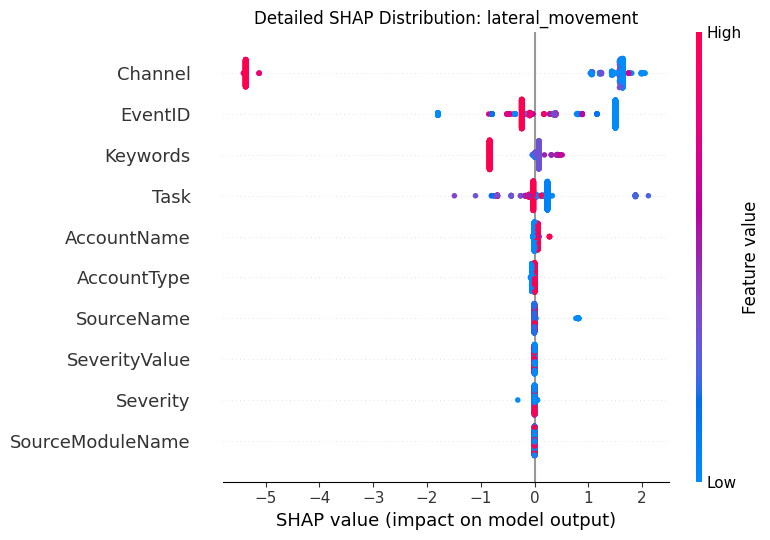

In [6]:
# This shows HOW each feature pushes predictions up or down
shap.summary_plot(
    shap_values[1],  # lateral_movement class
    X_sample,
    class_names=label_encoder.classes_,
    show=False
)
plt.title("Detailed SHAP Distribution: lateral_movement")
plt.tight_layout()
plt.savefig(r"C:\Research\EndpointXAI\xai\shap_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

ALERT #0
   AI Prediction: defense_evasion
   Actual Label:  defense_evasion
   Confidence: 100.0%

Feature values for this alert:
EventID             64.0
Task                47.0
Channel              7.0
SourceName           7.0
SourceModuleName     1.0
Severity             4.0
SeverityValue        4.0
AccountName          3.0
AccountType          2.0
Keywords             7.0
Name: 3107, dtype: float64


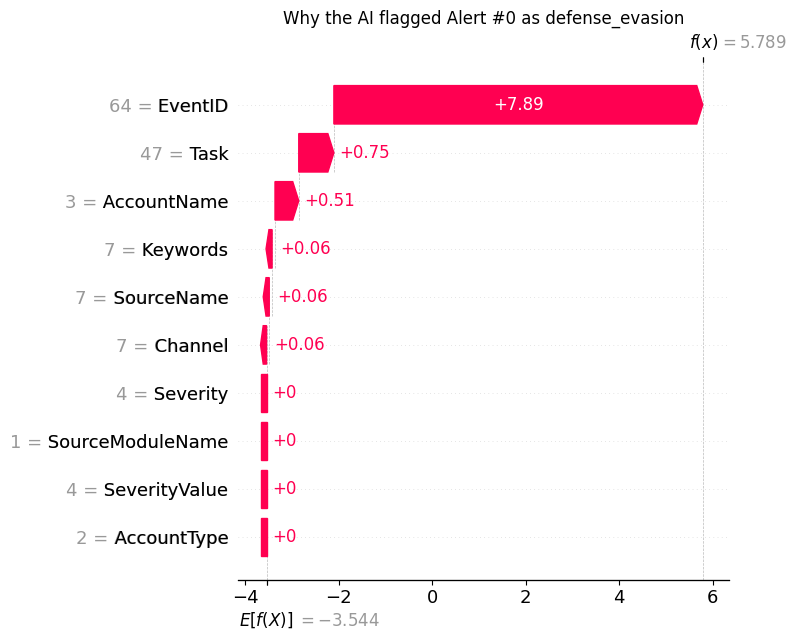

In [7]:
# Pick one specific alert and explain it in detail
alert_index = 0
predicted_class = xgb_model.predict(X_sample.iloc[[alert_index]])[0]
predicted_label = label_encoder.classes_[predicted_class]
actual_label = y_test.loc[X_sample.index[alert_index]] if X_sample.index[alert_index] in y_test.index else "?"

print(f"ALERT #{alert_index}")
print(f"   AI Prediction: {predicted_label}")
print(f"   Actual Label:  {actual_label}")
print(f"   Confidence: {xgb_model.predict_proba(X_sample.iloc[[alert_index]])[0][predicted_class]*100:.1f}%")
print("\nFeature values for this alert:")
print(X_sample.iloc[alert_index])

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[predicted_class][alert_index],
        base_values=explainer.expected_value[predicted_class],
        data=X_sample.iloc[alert_index].values,
        feature_names=X_sample.columns.tolist()
    ),
    show=False
)
plt.title(f"Why the AI flagged Alert #{alert_index} as {predicted_label}")
plt.tight_layout()
plt.savefig(r"C:\Research\EndpointXAI\xai\shap_single_alert.png", dpi=150, bbox_inches="tight")
plt.show()


In [8]:
import numpy as np

# Save SHAP values for use in dashboard later
np.save(r"C:\Research\EndpointXAI\xai\shap_values.npy", np.array(shap_values))
X_sample.to_csv(r"C:\Research\EndpointXAI\xai\shap_sample.csv", index=False)

print("SHAP values saved")
print("\nFiles created in xai/:")
print("  - shap_global_importance.png")
print("  - shap_defense_evasion.png")
print("  - shap_lateral_movement.png")
print("  - shap_persistence.png")
print("  - shap_distribution.png")
print("  - shap_single_alert.png")
print("  - shap_values.npy")


SHAP values saved

Files created in xai/:
  - shap_global_importance.png
  - shap_defense_evasion.png
  - shap_lateral_movement.png
  - shap_persistence.png
  - shap_distribution.png
  - shap_single_alert.png
  - shap_values.npy
